# Executive Compensation Analysis

## Data Sources
- **ORBIS** (`data/ORBIS_Abzug_DE_2005_2024.csv`): ~671K rows, German companies 2005–2024, financial statement data. Key match field: `SD_ISIN`.
- **Academic dataset 2008–2020** (`data/2008-2020/`): Three pipe-separated CSVs — `company_year` (aggregate comp), `person_year` (individual comp), `company_person` (exec bio). Key match: `isin`.
- **DAX Excel 2022–2024** (`data/202X/Executive_Compensation_202X.xlsx`): DAX companies only. Sheets: `Compensation`, `DAX` (company info + industry), `Members` (exec bio).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (12, 5)

DATA = Path('data')

---
## 1. ORBIS Financial Data

In [2]:
# Columns we actually need from the 286-column ORBIS file
ORBIS_COLS = [
    'bvdid', 'SD_ISIN', 'NAME_NATIVE', 'NAME_INTERNAT',
    'CATEGORY_OF_COMPANY',   # v=very large, l=large
    'CONSCODE',              # consolidation scope (C1=consolidated, U1=unconsolidated)
    'CLOSDATE_year',         # fiscal year
    'ORIG_CURRENCY', 'EXCHRATE',
    'EMPL',    # employees
    'TURN',    # turnover / net sales (thousands local currency)
    'OPRE',    # operating revenue (thousands local currency)
    'TOAS',    # total assets
    'SHFD',    # shareholders' funds
    'PLBT',    # P&L before tax
    'PLAT',    # P&L after tax
    'STAF',    # staff costs
    'GROS',    # gross profit
    'OPPL',    # operating P&L
    'ROE', 'ROA', 'ROCE',  # return ratios
    'SOLR',    # solvency ratio
    'CITY_NATIVE', 'COUNTRY', 'NUTS1',
    'dataset_source',
]

print('Loading ORBIS (671K rows, selecting key columns)...')
orbis_raw = pd.read_csv(
    DATA / 'ORBIS_Abzug_DE_2005_2024.csv',
    usecols=ORBIS_COLS,
    low_memory=False
)
print(f'Loaded: {orbis_raw.shape}')
orbis_raw.head(3)

Loading ORBIS (671K rows, selecting key columns)...
Loaded: (671626, 27)


,bvdid,CATEGORY_OF_COMPANY,CONSCODE,CLOSDATE_year,ORIG_CURRENCY,EXCHRATE,TOAS,SHFD,EMPL,OPRE,TURN,GROS,OPPL,PLBT,PLAT,STAF,ROE,ROCE,ROA,SOLR,SD_ISIN,NAME_INTERNAT,NAME_NATIVE,CITY_NATIVE,COUNTRY,NUTS1,dataset_source
0,BE0541946720,v,U1,2015,EUR,1.0887,2.188741e+08,2.185021e+08,NaN,0.00,0.00,NaN,-89155.82,4094824.73,3769967.56,32760.07,1.42,NaN,1.41,99.83,NaN,Dohler Belgium,Dohler Belgium,Darmstadt,Germany,NaN,101
1,BE0541946720,v,U1,2014,EUR,1.2141,1.506524e+08,1.505049e+08,NaN,0.00,0.00,NaN,-112520.42,3679266.30,3468965.87,38041.41,2.31,NaN,1.97,99.90,NaN,Dohler Belgium,Dohler Belgium,Darmstadt,Germany,NaN,101
2,BE0701938520,l,C1,2018,EUR,1.1450,1.102945e+08,1.109391e+07,NaN,445405.22,24045.01,NaN,-20394750.28,-20721075.44,-20725655.44,4851367.44,-186.82,NaN,-18.79,10.06,NaN,Ionity Gmbh,Ionity Gmbh,Munchen,Germany,NaN,101


In [3]:
print('--- ORBIS Basic Stats ---')
print(f'Rows: {len(orbis_raw):,}')
print(f'Unique companies (bvdid): {orbis_raw["bvdid"].nunique():,}')
print(f'Unique ISINs (SD_ISIN):   {orbis_raw["SD_ISIN"].nunique():,}')
print(f'Year range: {orbis_raw["CLOSDATE_year"].min()} – {orbis_raw["CLOSDATE_year"].max()}')
print(f'\nCompany category counts:')
print(orbis_raw['CATEGORY_OF_COMPANY'].value_counts())
print(f'\nConsolidation scope:')
print(orbis_raw['CONSCODE'].value_counts().head())
print(f'\nCurrencies:')
print(orbis_raw['ORIG_CURRENCY'].value_counts().head())

--- ORBIS Basic Stats ---
Rows: 671,626
Unique companies (bvdid): 77,188
Unique ISINs (SD_ISIN):   1,311
Year range: 2005 – 2024

Company category counts:
CATEGORY_OF_COMPANY
l    482446
v    189180
Name: count, dtype: int64

Consolidation scope:
CONSCODE
U1    501710
U2     86391
C2     73881
C1      9612
LF        32
Name: count, dtype: int64

Currencies:
ORIG_CURRENCY
EUR    670316
GBP      1278
USD        30
SEK         2
Name: count, dtype: int64


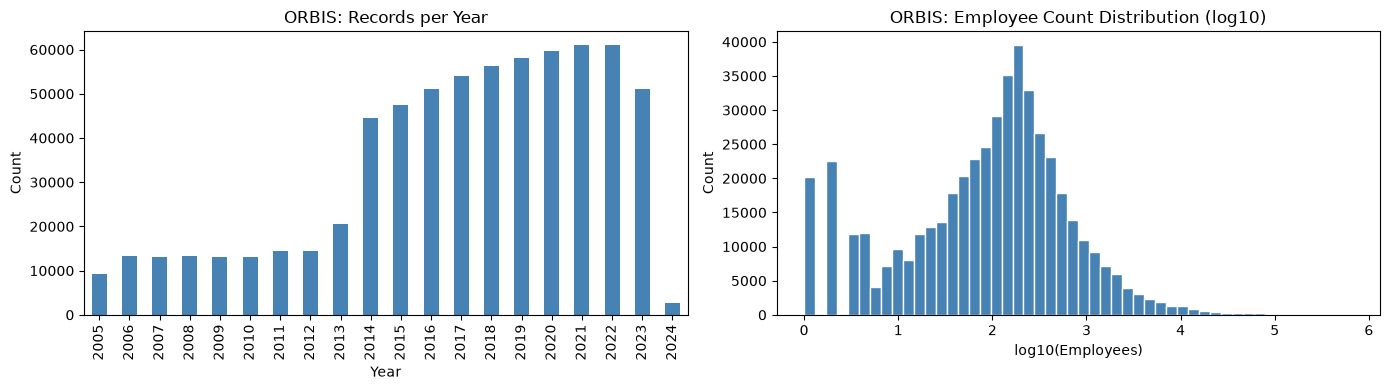

Employee stats: median=121, mean=800, max=671205


In [4]:
# Year coverage
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
orbis_raw['CLOSDATE_year'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('ORBIS: Records per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

# Employee distribution (log scale)
empl = orbis_raw['EMPL'].dropna()
empl = empl[empl > 0]
axes[1].hist(np.log10(empl), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('ORBIS: Employee Count Distribution (log10)')
axes[1].set_xlabel('log10(Employees)')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()
print(f'Employee stats: median={empl.median():.0f}, mean={empl.mean():.0f}, max={empl.max():.0f}')

In [5]:
# Normalize financial figures to EUR thousands
# ORBIS stores values in original currency (thousands), EXCHRATE converts to EUR
orbis = orbis_raw.copy()

fin_cols = ['TURN', 'OPRE', 'TOAS', 'SHFD', 'PLBT', 'PLAT', 'STAF', 'GROS', 'OPPL']
for col in fin_cols:
    orbis[f'{col}_eur'] = orbis[col] / orbis['EXCHRATE']

# Size buckets by employee count
def size_bucket(n):
    if pd.isna(n): return 'Unknown'
    if n < 250:   return 'Small (<250)'
    if n < 1000:  return 'Medium (250-999)'
    if n < 5000:  return 'Large (1k-5k)'
    if n < 25000: return 'Very Large (5k-25k)'
    return 'Mega (25k+)'

orbis['size_bucket'] = orbis['EMPL'].apply(size_bucket)

# Keep consolidated C1 records where available, otherwise U1
# For companies with both, prefer C1
orbis_c1 = orbis[orbis['CONSCODE'] == 'C1'].copy()
orbis_u1 = orbis[orbis['CONSCODE'] == 'U1'].copy()
orbis_u1_only = orbis_u1[~orbis_u1['bvdid'].isin(orbis_c1['bvdid'].unique())]
orbis_clean = pd.concat([orbis_c1, orbis_u1_only], ignore_index=True)

print(f'C1 (consolidated):  {len(orbis_c1):,} rows')
print(f'U1 (unconsolidated): {len(orbis_u1):,} rows')
print(f'After dedup (prefer C1): {len(orbis_clean):,} rows')
print(f'Unique companies: {orbis_clean["bvdid"].nunique():,}')
print(f'ISIN coverage: {orbis_clean["SD_ISIN"].notna().sum():,} rows have ISIN')

C1 (consolidated):  9,612 rows
U1 (unconsolidated): 501,710 rows
After dedup (prefer C1): 510,591 rows
Unique companies: 67,041
ISIN coverage: 5,568 rows have ISIN


---
## 2. Compensation Data 2008–2020 (Academic Dataset)

In [6]:
# company_year: aggregate compensation per company per fiscal year
cy = pd.read_csv(DATA / '2008-2020/company_year.csv', sep='|')
cy['isin'] = cy['isin'].str.strip('"')
cy['source'] = 'academic_2008-2020'
print('company_year shape:', cy.shape)
print('Columns:', cy.columns.tolist())
cy.head(3)

company_year shape: (1467, 25)
Columns: ['isin', 'year', 'company_shortname', 'company_name', 'opting_out', 'index_listing', 'new_cnameshort', 'n_executives', 'days_bt', 'fy_begin', 'fy_end', 'salary_bt', 'one_year_bonus_bt', 'multi_year_bonus_bt', 'multi_year_bonus_grants_bt', 'multi_year_bonus_payout_bt', 'total_equity_grants_bt', 'stock_grants_bt', 'option_grants_bt', 'other_annual_bt', 'total_comp_bt', 'one_time_payment_bt', 'pension_bt', 'total_comp_pens_and_one_time_bt', 'source']


,isin,year,company_shortname,company_name,opting_out,index_listing,new_cnameshort,n_executives,days_bt,fy_begin,fy_end,salary_bt,one_year_bonus_bt,multi_year_bonus_bt,multi_year_bonus_grants_bt,multi_year_bonus_payout_bt,total_equity_grants_bt,stock_grants_bt,option_grants_bt,other_annual_bt,total_comp_bt,one_time_payment_bt,pension_bt,total_comp_pens_and_one_time_bt,source
0,DE0005545503,2017,1&1 Drillisch,1&1 Drillisch AG,0,NaN,NaN,3,820,01jan2017,31dec2017,1400.0,1450.0,0.0,1662.0,0.0,0.0,0.0,0.0,45.0,2895.0,1907.0,2.0,4804.0,academic_2008-2020
1,DE0005545503,2018,1&1 Drillisch,1&1 Drillisch AG,0,MDAX,NaN,2,730,01jan2018,31dec2018,700.0,531.0,300.0,100.0,300.0,0.0,0.0,0.0,25.0,1556.0,0.0,1.0,1557.0,academic_2008-2020
2,IT0000062072,2006,AMB Generali,AMB Generali Holding AG,1,MDAX,NaN,2,730,01jan2006,31dec2006,1119.0,1998.0,0.0,NaN,NaN,0.0,0.0,0.0,13.0,3130.0,0.0,0.0,3130.0,academic_2008-2020


In [7]:
# person_year: individual executive compensation per year
py_df = pd.read_csv(DATA / '2008-2020/person_year.csv', sep='|')
py_df['isin'] = py_df['isin'].str.strip('"')
print('person_year shape:', py_df.shape)
print('Columns:', py_df.columns.tolist())
py_df.head(3)

person_year shape: (6726, 28)
Columns: ['company_person_id', 'year', 'isin', 'company_shortname', 'company_name', 'exec_id', 'exec_fullname', 'days', 'ceo_flag_eoy', 'cfo_flag_eoy', 'date_begin_ceo', 'date_end_ceo', 'date_begin_cfo', 'date_end_cfo', 'salary', 'one_year_bonus', 'multi_year_bonus', 'multi_year_bonus_grants', 'multi_year_bonus_payout', 'total_equity_grants', 'stock_grants', 'option_grants', 'other_annual_comp', 'total_comp', 'pension', 'pension_missing', 'one_time_payment', 'total_comp_pens_and_one_time']


,company_person_id,year,isin,company_shortname,company_name,exec_id,exec_fullname,days,ceo_flag_eoy,cfo_flag_eoy,date_begin_ceo,date_end_ceo,date_begin_cfo,date_end_cfo,salary,one_year_bonus,multi_year_bonus,multi_year_bonus_grants,multi_year_bonus_payout,total_equity_grants,stock_grants,option_grants,other_annual_comp,total_comp,pension,pension_missing,one_time_payment,total_comp_pens_and_one_time
0,56.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,53.0,André Driesen,365.0,NaN,1.0,NaN,NaN,01jan2017,31dec2017,400.0,350.0,0.0,100.0,0.0,0.0,0.0,0.0,12.0,762.0,1.0,0.0,NaN,763.0
1,1198.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,1138.0,Martin Witt,91.0,NaN,NaN,NaN,NaN,NaN,NaN,300.0,200.0,0.0,0.0,0.0,0.0,0.0,0.0,13.0,513.0,0.0,0.0,NaN,513.0
2,1664.0,2017,DE0005545503,1&1 Drillisch,1&1 Drillisch AG,1578.0,Vlasios Choulidis,364.0,1.0,NaN,01jan2017,31dec2017,NaN,NaN,700.0,900.0,0.0,1562.0,0.0,0.0,0.0,0.0,20.0,1620.0,1.0,0.0,1907.0,3528.0


In [8]:
# company_person: static executive bio data
cp = pd.read_csv(DATA / '2008-2020/company_person.csv', sep='|')
cp['isin'] = cp['isin'].str.strip('"')
print('company_person shape:', cp.shape)
print('Columns:', cp.columns.tolist())
cp.head(3)

company_person shape: (1721, 18)
Columns: ['company_person_id', 'isin', 'company_shortname', 'exec_id', 'exec_academic_title', 'exec_firstname', 'exec_lastname', 'exec_fullname', 'female', 'nationality', 'date_of_birth', 'company_entry_date', 'board_entry_date', 'board_exit_date', 'board_entry_date_private', 'board_exit_date_private', 'company_entry_date2', 'board_entry_date2']


,company_person_id,isin,company_shortname,exec_id,exec_academic_title,exec_firstname,exec_lastname,exec_fullname,female,nationality,date_of_birth,company_entry_date,board_entry_date,board_exit_date,board_entry_date_private,board_exit_date_private,company_entry_date2,board_entry_date2
0,2,LU0269583422,GAGFAH,1,NaN,A. Udo,Bachmann,A. Udo Bachmann,0,German,01jan1953,01jan1990,01jan1992,31jul2006,NaN,NaN,NaN,NaN
1,3,DE0007664005,Volkswagen,2,NaN,Abraham,Schot,Abraham Schot,0,Dutch,12jul1961,01jul2011,01jan2019,31mar2020,NaN,NaN,NaN,NaN
2,4,DE000SYM9999,Symrise,3,NaN,Achim,Daub,Achim Daub,0,German,22may1962,01nov2006,01dec2006,31mar2021,NaN,NaN,NaN,NaN


In [9]:
print('--- Company Year Compensation Stats (in TEUR) ---')
comp_cols = ['salary_bt', 'one_year_bonus_bt', 'multi_year_bonus_bt', 'total_equity_grants_bt', 'total_comp_bt']
print(cy[comp_cols].describe().round(0))

print('\n--- Person Year Compensation Stats (TEUR) ---')
p_cols = ['salary', 'one_year_bonus', 'multi_year_bonus', 'total_equity_grants', 'total_comp']
print(py_df[p_cols].describe().round(0))

print('\n--- Year distribution ---')
print(py_df['year'].value_counts().sort_index())

--- Company Year Compensation Stats (in TEUR) ---
       salary_bt  one_year_bonus_bt  multi_year_bonus_bt  total_equity_grants_bt  total_comp_bt
count     1467.0             1467.0               1467.0                  1467.0         1467.0
mean      3355.0             3217.0               1141.0                  2738.0        10787.0
std       2699.0             3694.0               3759.0                  7600.0        11486.0
min          0.0                0.0                  0.0                     0.0            0.0
25%       1628.0              833.0                  0.0                     0.0         4206.0
50%       2738.0             2067.0                  0.0                   935.0         7078.0
75%       4155.0             4296.0                850.0                  3630.0        13992.0
max      29400.0            31729.0              58320.0                243342.0       247760.0

--- Person Year Compensation Stats (TEUR) ---
       salary  one_year_bonus  multi_ye

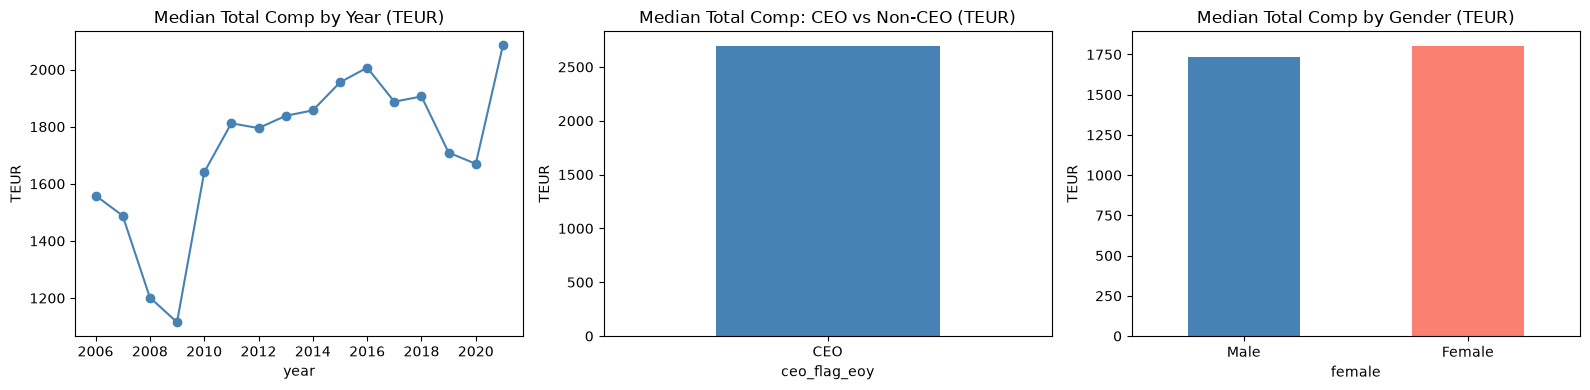

In [10]:
# Merge person-year with bio data to get gender, age, CEO flag
exec_data = py_df.merge(
    cp[['company_person_id', 'exec_id', 'female', 'nationality', 'date_of_birth', 'board_entry_date']],
    on='company_person_id', how='left'
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Total comp over years
tc_yr = exec_data.groupby('year')['total_comp'].median()
tc_yr.plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Median Total Comp by Year (TEUR)')
axes[0].set_ylabel('TEUR')

# CEO vs non-CEO (only plot if both groups exist)
ceo_comp = exec_data[exec_data['ceo_flag_eoy'].isin([0, 1])].groupby('ceo_flag_eoy')['total_comp'].median()
ceo_comp.index = ceo_comp.index.map({0: 'Non-CEO', 1: 'CEO'})
ceo_comp.plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange'])
axes[1].set_title('Median Total Comp: CEO vs Non-CEO (TEUR)')
axes[1].set_ylabel('TEUR')
axes[1].tick_params(axis='x', rotation=0)

# Gender
gender_comp = exec_data[exec_data['female'].isin([0, 1])].groupby('female')['total_comp'].median()
gender_comp.index = gender_comp.index.map({0: 'Male', 1: 'Female'})
gender_comp.plot(kind='bar', ax=axes[2], color=['steelblue', 'salmon'])
axes[2].set_title('Median Total Comp by Gender (TEUR)')
axes[2].set_ylabel('TEUR')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


---
## 3. DAX Compensation Data 2022–2024 (Excel)

In [11]:
import openpyxl

def _valid_col(c):
    """Return True if c is a usable column name."""
    if c is None:
        return False
    if isinstance(c, float) and np.isnan(c):
        return False
    return isinstance(c, str)

def read_excel_sheet_by_header(filepath, sheetname, header_value='cnameshort', max_scan=10):
    """Read a sheet where the machine-readable header row starts with header_value."""
    wb = openpyxl.load_workbook(filepath, read_only=True, data_only=True)
    ws = wb[sheetname]
    all_rows = list(ws.iter_rows(values_only=True))
    wb.close()

    header_idx = None
    for i, row in enumerate(all_rows[:max_scan]):
        if row and row[0] == header_value:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f'Could not find header row "{header_value}" in {sheetname}')

    header = list(all_rows[header_idx])
    # only keep columns with a real string name
    valid_idx = [i for i, c in enumerate(header) if _valid_col(c)]
    valid_header = [header[i] for i in valid_idx]

    data = []
    for r in all_rows[header_idx + 1:]:
        if r[0] is not None and isinstance(r[0], str) and not r[0].startswith('='):
            data.append([r[i] if i < len(r) else None for i in valid_idx])
    return pd.DataFrame(data, columns=valid_header)


def read_dax_sheet(filepath, year):
    """Read DAX company info sheet."""
    wb_tmp = openpyxl.load_workbook(filepath, read_only=True)
    sh = next(s for s in wb_tmp.sheetnames if 'DAX' in s)
    wb_tmp.close()

    wb = openpyxl.load_workbook(filepath, read_only=True, data_only=True)
    ws = wb[sh]
    all_rows = list(ws.iter_rows(values_only=True))
    wb.close()

    header_idx = None
    for i, row in enumerate(all_rows[:10]):
        if row and isinstance(row[0], str) and row[0].startswith('cnameshort'):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f'No header in DAX sheet {sh}')

    header = list(all_rows[header_idx])
    valid_idx = [i for i, c in enumerate(header) if _valid_col(c) and not c.startswith('=')]
    valid_header = [header[i] for i in valid_idx]
    new_names = [str(c).split('(')[0].strip().lower().replace(' ', '_') for c in valid_header]

    data = []
    for r in all_rows[header_idx + 1:]:
        if r[0] is not None and isinstance(r[0], str):
            data.append([r[i] if i < len(r) else None for i in valid_idx])

    df = pd.DataFrame(data, columns=new_names)
    df['year'] = year
    return df


def read_comp_sheet(filepath, year):
    """Read compensation sheet with exec-level data."""
    wb_tmp = openpyxl.load_workbook(filepath, read_only=True)
    sh = next(s for s in wb_tmp.sheetnames if s.startswith('Compensation'))
    wb_tmp.close()
    df = read_excel_sheet_by_header(filepath, sh)
    df = df[df['pfirstname'].notna() & df['pfirstname'].apply(lambda x: isinstance(x, str))]
    core = ['cnameshort', 'pfirstname', 'psurname', 'fix', 'sti', 'lti', 'others', 'pension', 'payoff']
    existing = [c for c in core if c in df.columns]
    df = df[existing].copy()
    df['year'] = year
    for c in ['fix', 'sti', 'lti', 'others', 'pension', 'payoff']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df


def read_members_sheet(filepath, year):
    """Read board members sheet."""
    wb_tmp = openpyxl.load_workbook(filepath, read_only=True)
    sh = next(s for s in wb_tmp.sheetnames if s.startswith('Members'))
    wb_tmp.close()
    df = read_excel_sheet_by_header(filepath, sh)
    df = df[df['pfirstname'].notna() & df['pfirstname'].apply(lambda x: isinstance(x, str))]
    core = ['cnameshort', 'pfirstname', 'psurname', 'pdob', 'pgender', 'pnationality', 'pboardentry', 'pboardexit']
    existing = [c for c in core if c in df.columns]
    df = df[existing].copy()
    df['year'] = year
    return df


print('Helper functions defined.')


Helper functions defined.


In [12]:
excel_files = {
    2022: DATA / '2022/Executive_Compensation_2022.xlsx',
    2023: DATA / '2023/Executive_Compensation_ 2023.xlsx',
    2024: DATA / '2024/Executive_Compensation_2024.xlsx',
}

dax_dfs, comp_dfs, members_dfs = [], [], []

for year, fpath in excel_files.items():
    print(f'Loading {year}...')
    try:
        dax_dfs.append(read_dax_sheet(fpath, year))
    except Exception as e:
        print(f'  DAX sheet error: {e}')
    try:
        comp_dfs.append(read_comp_sheet(fpath, year))
    except Exception as e:
        print(f'  Comp sheet error: {e}')
    try:
        members_dfs.append(read_members_sheet(fpath, year))
    except Exception as e:
        print(f'  Members sheet error: {e}')

dax_all = pd.concat(dax_dfs, ignore_index=True)
comp_all = pd.concat(comp_dfs, ignore_index=True)
members_all = pd.concat(members_dfs, ignore_index=True)

print(f'\nDAX info: {dax_all.shape}  columns: {dax_all.columns.tolist()}')
print(f'Comp data: {comp_all.shape}')
print(f'Members: {members_all.shape}')

Loading 2022...
Loading 2023...
Loading 2024...

DAX info: (126, 12)  columns: ['cnameshort', 'cnamelong', 'clegalform', 'fybegin', 'fyend', 'dax_entry', 'dax_exit', 'cpersonnelexpenses', 'cnremployees', 'ø_personalaufwand', 'year', 'cinformation']
Comp data: (771, 10)
Members: (771, 9)


In [13]:
print('DAX companies per year:', dax_all.groupby('year').size().to_dict())
dax_all.head(3)

DAX companies per year: {2022: 42, 2023: 42, 2024: 42}


,cnameshort,cnamelong,clegalform,fybegin,fyend,dax_entry,dax_exit,cpersonnelexpenses,cnremployees,ø_personalaufwand,year,cinformation
0,Adidas,Adidas,AG,2022-01-01,2022-12-31,1998-06-22,NaN,2856000.0,59258.0,48.196024,2022,NaN
1,Allianz,NaN,SE,2022-01-01,2022-12-31,1988-07-01,Erbringung von Finanz- und Versicherungsdienst...,13965000.0,159253.0,87.690656,2022,NaN
2,BASF,NaN,SE,2022-01-01,2022-12-31,1988-07-01,NaN,11400000.0,111481.0,102.259578,2022,NaN


In [14]:
# Compute total comp = fix + sti + lti + pension + payoff + others
pay_parts = [c for c in ['fix', 'sti', 'lti', 'pension', 'payoff', 'others'] if c in comp_all.columns]
comp_all['total_comp'] = comp_all[pay_parts].sum(axis=1, min_count=1)
comp_all['exec_name'] = comp_all['pfirstname'].fillna('') + ' ' + comp_all['psurname'].fillna('')
comp_all['exec_name'] = comp_all['exec_name'].str.strip()

print('Comp (2022-2024) stats (TEUR):')
print(comp_all.groupby('year')[['fix', 'sti', 'lti', 'total_comp']].median().round(0))
comp_all.head(3)

Comp (2022-2024) stats (TEUR):
        fix    sti     lti  total_comp
year                                  
2022  832.0  788.0   991.0      3201.0
2023  831.0  764.0  1092.0      3340.0
2024  918.0  831.0  1190.0      3414.0


,cnameshort,pfirstname,psurname,fix,sti,lti,others,pension,payoff,year,total_comp,exec_name
0,Adidas,Kasper,Rorsted,1898.63,0.0,0.0,65.117,1133.852,14998.03,2022,18095.629,Kasper Rorsted
1,Adidas,Roland,Auschel,920.00,0.0,0.0,34.106,471.560,0.00,2022,1425.666,Roland Auschel
2,Adidas,Brian,Grevy,800.00,0.0,0.0,27.990,453.052,0.00,2022,1281.042,Brian Grevy


In [15]:
# Extract industry from DAX info sheet
# The 'cinformation' or similar column has German industry description
industry_col = [c for c in dax_all.columns if 'info' in c or 'sector' in c or 'industrie' in c]
print('Potential industry columns:', industry_col)
print('DAX columns:', dax_all.columns.tolist())

Potential industry columns: ['cinformation']
DAX columns: ['cnameshort', 'cnamelong', 'clegalform', 'fybegin', 'fyend', 'dax_entry', 'dax_exit', 'cpersonnelexpenses', 'cnremployees', 'ø_personalaufwand', 'year', 'cinformation']


In [16]:
# Build industry mapping from DAX sheet (use latest year available per company)
# The column with industry text is typically the 8th column ('cinformation' in 2023/2024)
if 'cinformation' in dax_all.columns:
    industry_map = (
        dax_all[dax_all['cinformation'].notna()]
        .sort_values('year', ascending=False)
        .drop_duplicates('cnameshort')
        [['cnameshort', 'cinformation']]
        .rename(columns={'cinformation': 'industry_de'})
    )
else:
    # Fall back to first string column after the date cols
    str_cols = [c for c in dax_all.columns if dax_all[c].dtype == object and c != 'cnameshort']
    print('String columns in DAX sheet:', str_cols)
    industry_col_name = str_cols[0] if str_cols else None
    if industry_col_name:
        industry_map = (
            dax_all[dax_all[industry_col_name].notna()]
            .sort_values('year', ascending=False)
            .drop_duplicates('cnameshort')
            [['cnameshort', industry_col_name]]
            .rename(columns={industry_col_name: 'industry_de'})
        )
    else:
        industry_map = pd.DataFrame(columns=['cnameshort', 'industry_de'])

print(f'Industry map: {len(industry_map)} companies')
industry_map.head(10)

Industry map: 41 companies


,cnameshort,industry_de
108,MTU,Flugzeugtriebwerke
109,Munich RE,Rückversicherungsgesellschaft
110,Porsche AG,Automobil
111,Porsche SE,Beteiligungsgesellschaft
112,Qiagen,Molekulardiagnostik
113,Rheinmetall,Verteidigungs- und Automobilzulieferer
114,RWE,Energieversorgung
115,SAP,Softwarelösungen
91,Brenntag,Chemiedistributeur
90,BMW,Automobil


In [17]:
# Map German industry descriptions to English sector labels
SECTOR_MAP = {
    'Automobil':          'Automotive',
    'Auto':               'Automotive',
    'Flugzeug':           'Aerospace & Defense',
    'Chemie':             'Chemicals',
    'Pharma':             'Pharma & Healthcare',
    'Versicherung':       'Insurance & Finance',
    'Finanz':             'Insurance & Finance',
    'Bank':               'Insurance & Finance',
    'Software':           'Technology',
    'Technologie':        'Technology',
    'Telekommunikation':  'Telecom',
    'Energie':            'Energy & Utilities',
    'Logistik':           'Logistics & Transport',
    'Handel':             'Retail & Consumer',
    'Konsumg':            'Retail & Consumer',
    'Sport':              'Retail & Consumer',
    'Bau':                'Construction & Real Estate',
    'Immobilien':         'Construction & Real Estate',
    'Industrie':          'Industrial',
    'Medizin':            'Pharma & Healthcare',
    'Medien':             'Media',
    'Bergbau':            'Mining & Materials',
    'Stahl':              'Mining & Materials',
    'Hautpflege':         'Retail & Consumer',
}

def map_sector(text):
    if not isinstance(text, str):
        return 'Other'
    for key, sector in SECTOR_MAP.items():
        if key.lower() in text.lower():
            return sector
    return 'Other'

if len(industry_map) > 0:
    industry_map['sector'] = industry_map['industry_de'].apply(map_sector)
    print(industry_map['sector'].value_counts())

sector
Automotive                    7
Other                         7
Insurance & Finance           5
Pharma & Healthcare           5
Retail & Consumer             4
Technology                    3
Chemicals                     3
Aerospace & Defense           2
Energy & Utilities            2
Construction & Real Estate    1
Telecom                       1
Logistics & Transport         1
Name: count, dtype: int64


---
## 4. Merge ORBIS with Compensation Data

In [18]:
# Prepare ORBIS ISIN index
orbis_isin = orbis_clean[orbis_clean['SD_ISIN'].notna()].copy()
orbis_isin['SD_ISIN'] = orbis_isin['SD_ISIN'].str.strip()
print(f'ORBIS rows with ISIN: {len(orbis_isin):,}')

# Key ORBIS features to join
ORBIS_FEATURES = [
    'SD_ISIN', 'NAME_NATIVE', 'CLOSDATE_year', 'CATEGORY_OF_COMPANY', 'size_bucket',
    'EMPL', 'TURN_eur', 'OPRE_eur', 'TOAS_eur', 'SHFD_eur', 'PLBT_eur', 'PLAT_eur',
    'STAF_eur', 'GROS_eur', 'OPPL_eur', 'ROE', 'ROA', 'ROCE', 'SOLR',
    'NUTS1', 'CITY_NATIVE'
]
orbis_feat = orbis_isin[ORBIS_FEATURES].copy()
orbis_feat = orbis_feat.rename(columns={'CLOSDATE_year': 'year', 'SD_ISIN': 'isin'})

ORBIS rows with ISIN: 5,568


In [19]:
# === Merge 2008-2020 company-level comp with ORBIS ===
cy_orbis = cy.merge(orbis_feat, on=['isin', 'year'], how='left')

match_pct = cy_orbis['EMPL'].notna().mean() * 100
print(f'company_year rows: {len(cy_orbis)}')
print(f'ORBIS match rate: {match_pct:.1f}%')
cy_orbis[['isin', 'year', 'company_shortname', 'total_comp_bt', 'EMPL', 'TURN_eur', 'TOAS_eur']].head(5)

company_year rows: 1467
ORBIS match rate: 8.5%


,isin,year,company_shortname,total_comp_bt,EMPL,TURN_eur,TOAS_eur
0,DE0005545503,2017,1&1 Drillisch,2895.0,NaN,NaN,NaN
1,DE0005545503,2018,1&1 Drillisch,1556.0,NaN,NaN,NaN
2,IT0000062072,2006,AMB Generali,3130.0,NaN,NaN,NaN
3,IT0000062072,2007,AMB Generali,3016.0,NaN,NaN,NaN
4,DE0005085906,2006,AWD,3095.0,2096.0,7.280014e+08,4.021008e+08


In [20]:
# === Merge 2008-2020 person-level comp with ORBIS ===
py_orbis = py_df.merge(orbis_feat, on=['isin', 'year'], how='left')
py_orbis = py_orbis.merge(
    cp[['company_person_id', 'female', 'nationality', 'exec_fullname']],
    on='company_person_id', how='left'
)

match_pct = py_orbis['EMPL'].notna().mean() * 100
print(f'person_year rows: {len(py_orbis)}')
print(f'ORBIS match rate: {match_pct:.1f}%')
py_orbis[['isin', 'year', 'exec_fullname_x', 'total_comp', 'EMPL', 'TURN_eur', 'ROA']].head(5)

person_year rows: 6726
ORBIS match rate: 8.3%


,isin,year,exec_fullname_x,total_comp,EMPL,TURN_eur,ROA
0,DE0005545503,2017,André Driesen,762.0,NaN,NaN,NaN
1,DE0005545503,2017,Martin Witt,513.0,NaN,NaN,NaN
2,DE0005545503,2017,Vlasios Choulidis,1620.0,NaN,NaN,NaN
3,DE0005545503,2018,André Driesen,1062.0,NaN,NaN,NaN
4,DE0005545503,2018,Martin Witt,494.0,NaN,NaN,NaN


In [21]:
# === Merge 2022-2024 Excel comp with DAX company info (employees, sector) ===
print('DAX columns:', dax_all.columns.tolist())

# dax_all already has clean column names from read_dax_sheet
dax_info = dax_all.copy()

# add sector info
if len(industry_map) > 0:
    dax_info = dax_info.merge(industry_map[['cnameshort', 'industry_de', 'sector']], on='cnameshort', how='left')

# columns to bring from dax_info (drop redundant ones)
dax_extra = [c for c in dax_info.columns if c not in ['cnameshort', 'year', 'cnamelong', 'clegalform', 'fybegin', 'fyend', 'dax_entry', 'dax_exit']]
merge_cols = ['cnameshort', 'year'] + dax_extra

comp_dax = comp_all.merge(dax_info[merge_cols].drop_duplicates(['cnameshort', 'year']),
                          on=['cnameshort', 'year'], how='left')

print(f'\nComp+DAX merged: {comp_dax.shape}')
comp_dax[['cnameshort', 'year', 'exec_name', 'fix', 'sti', 'lti', 'total_comp']].head(5)


DAX columns: ['cnameshort', 'cnamelong', 'clegalform', 'fybegin', 'fyend', 'dax_entry', 'dax_exit', 'cpersonnelexpenses', 'cnremployees', 'ø_personalaufwand', 'year', 'cinformation']

Comp+DAX merged: (771, 18)


,cnameshort,year,exec_name,fix,sti,lti,total_comp
0,Adidas,2022,Kasper Rorsted,1898.63,0.0,0.0,18095.629
1,Adidas,2022,Roland Auschel,920.00,0.0,0.0,1425.666
2,Adidas,2022,Brian Grevy,800.00,0.0,0.0,1281.042
3,Adidas,2022,Harm Ohlmeyer,900.00,0.0,0.0,1450.546
4,Adidas,2022,Amanda Rajkumar,800.00,0.0,0.0,1332.408


---
## 5. Build Unified Dataset for Modeling

In [22]:
# Build a unified person-year compensation dataset spanning 2008-2024

# --- Source A: 2008-2020 person level ---
df_a = py_orbis.copy()
# exec_fullname may have suffix _x after merge
exec_name_col = 'exec_fullname_x' if 'exec_fullname_x' in df_a.columns else 'exec_fullname'
df_a['exec_name']   = df_a.get(exec_name_col, pd.Series('Unknown', index=df_a.index))
df_a['fix']         = df_a['salary']
df_a['bonus']       = df_a['one_year_bonus'].fillna(0)
df_a['equity']      = df_a['total_equity_grants'].fillna(0)
df_a['revenue_eur'] = df_a['TURN_eur']
df_a['assets_eur']  = df_a['TOAS_eur']
df_a['roa']         = df_a['ROA']
df_a['empl']        = df_a['EMPL']
df_a['size_bucket'] = df_a['size_bucket']
df_a['ceo_flag']    = df_a['ceo_flag_eoy'].fillna(0)
df_a['female']      = df_a['female'].fillna(0)
df_a['sector']      = 'Unknown'
df_a['source']      = 'academic_2008-2020'

keep_a = ['year', 'isin', 'exec_name', 'ceo_flag', 'female', 'total_comp',
          'fix', 'bonus', 'equity', 'empl', 'revenue_eur', 'assets_eur',
          'roa', 'size_bucket', 'sector', 'source']
df_a = df_a[[c for c in keep_a if c in df_a.columns]].copy()

# --- Source B: 2022-2024 DAX ---
df_b = comp_dax.copy()
df_b['isin']        = None
df_b['bonus']       = df_b['sti']   if 'sti'  in df_b.columns else np.nan
df_b['equity']      = df_b['lti']   if 'lti'  in df_b.columns else np.nan
df_b['ceo_flag']    = 0
df_b['female']      = 0

emp_col = next((c for c in df_b.columns if 'nremp' in c.lower() or 'cnremp' in c.lower()), None)
df_b['empl'] = pd.to_numeric(df_b[emp_col], errors='coerce') if emp_col else np.nan
df_b['revenue_eur'] = np.nan
df_b['assets_eur']  = np.nan
df_b['roa']         = np.nan
df_b['size_bucket'] = df_b['empl'].apply(size_bucket)
df_b['sector']      = df_b['sector'] if 'sector' in df_b.columns else 'Unknown'
df_b['source']      = 'dax_2022-2024'

keep_b = ['year', 'isin', 'exec_name', 'ceo_flag', 'female', 'total_comp',
          'fix', 'bonus', 'equity', 'empl', 'revenue_eur', 'assets_eur',
          'roa', 'size_bucket', 'sector', 'source']
df_b = df_b[[c for c in keep_b if c in df_b.columns]].copy()

unified = pd.concat([df_a, df_b], ignore_index=True)
unified = unified[unified['total_comp'].notna() & (unified['total_comp'] > 0)].copy()

print(f'Unified dataset: {unified.shape}')
print(f'Year range: {unified["year"].min()} – {unified["year"].max()}')
print(f'Sources: {unified["source"].value_counts().to_dict()}')
unified.describe().round(0)


Unified dataset: (7468, 16)
Year range: 2006 – 2024
Sources: {'academic_2008-2020': 6697, 'dax_2022-2024': 771}


,year,ceo_flag,female,total_comp,fix,bonus,equity,empl,revenue_eur,assets_eur,roa
count,7468.0,7468.0,7468.0,7468.0,7468.0,7468.0,7468.0,1328.0,5.570000e+02,5.570000e+02,557.0
mean,2015.0,0.0,0.0,2267.0,681.0,649.0,596.0,79127.0,4.280822e+09,6.188525e+09,4.0
std,5.0,0.0,0.0,1806.0,439.0,674.0,889.0,130964.0,4.705890e+09,9.217833e+09,13.0
min,2006.0,0.0,0.0,16.0,0.0,-110.0,0.0,38.0,3.203310e+08,3.473998e+08,-65.0
25%,2010.0,0.0,0.0,1024.0,400.0,180.0,0.0,9825.0,1.080393e+09,1.198815e+09,1.0
50%,2015.0,0.0,0.0,1873.0,600.0,475.0,328.0,25529.0,2.330825e+09,2.263118e+09,4.0
75%,2019.0,0.0,0.0,2995.0,833.0,915.0,901.0,91000.0,4.650737e+09,7.292392e+09,8.0
max,2024.0,1.0,1.0,23450.0,3800.0,6680.0,19151.0,654359.0,1.794400e+10,3.534700e+10,61.0


---
## 6. Exploratory Analysis

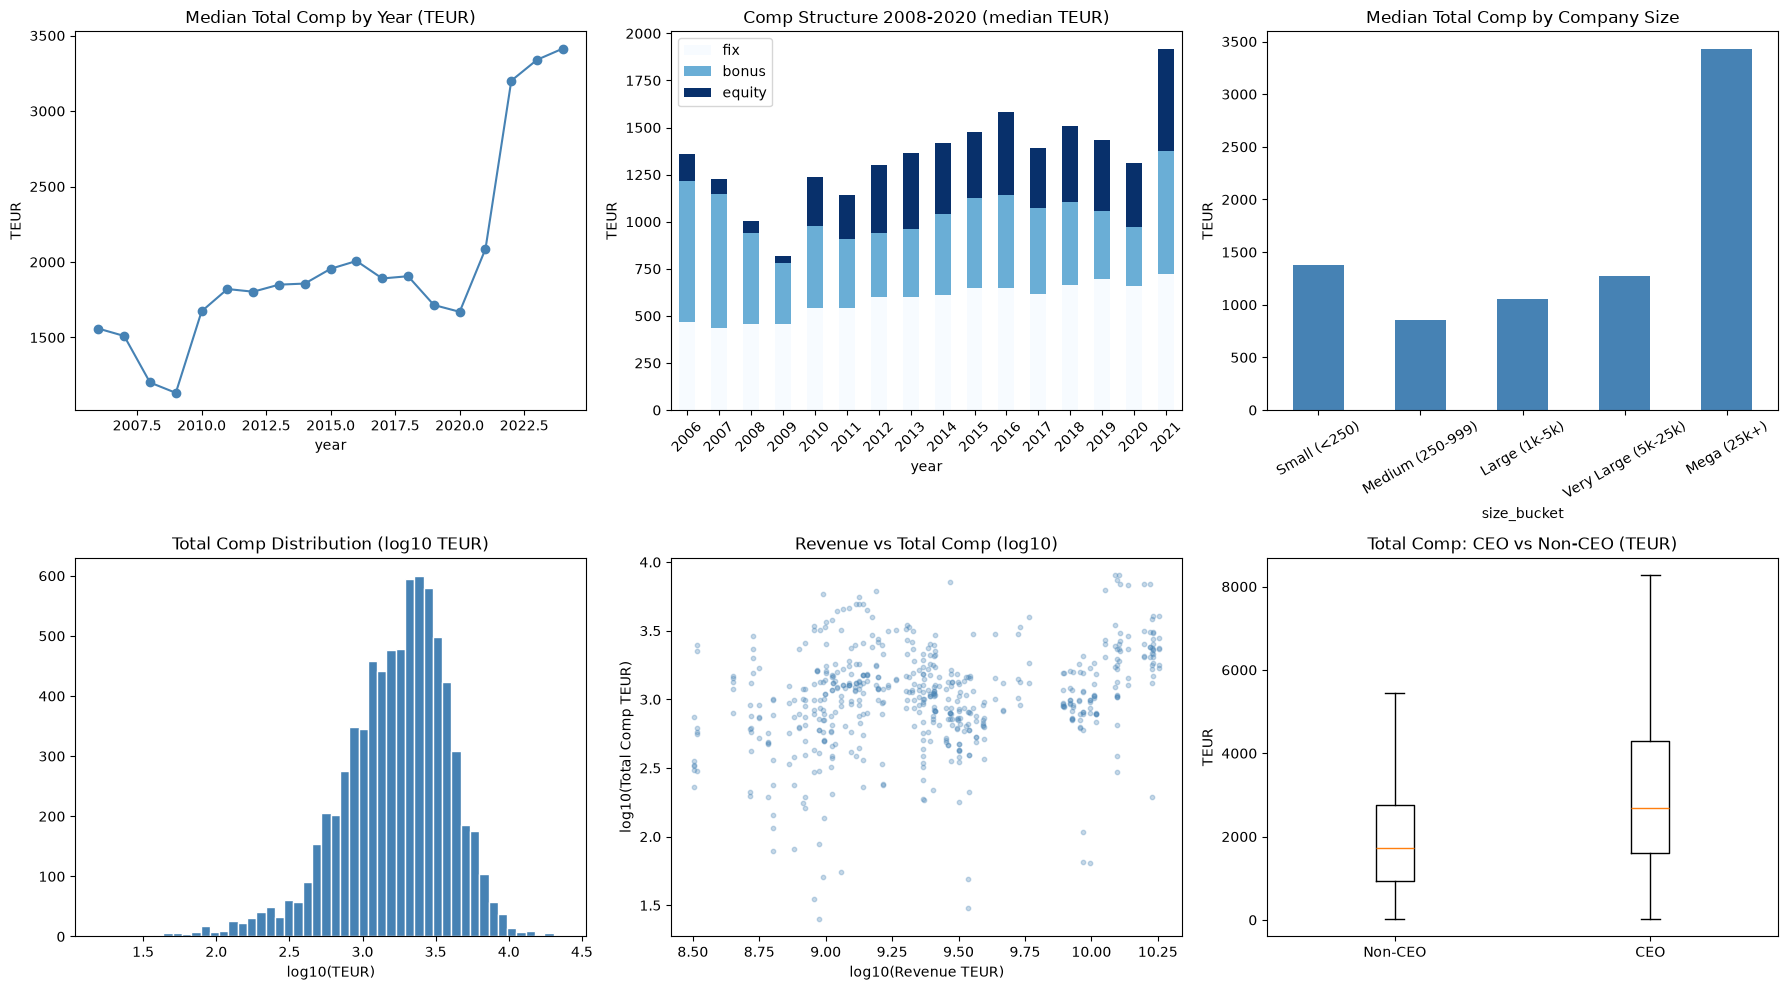

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Median total comp by year
tc_yr = unified.groupby('year')['total_comp'].median()
tc_yr.plot(ax=axes[0, 0], marker='o', color='steelblue')
axes[0, 0].set_title('Median Total Comp by Year (TEUR)')
axes[0, 0].set_ylabel('TEUR')

# 2. Comp structure breakdown (fix vs variable) for 2008-2020
struct = unified[unified['source'] == 'academic_2008-2020'].groupby('year')[['fix', 'bonus', 'equity']].median()
struct.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='Blues')
axes[0, 1].set_title('Comp Structure 2008-2020 (median TEUR)')
axes[0, 1].set_ylabel('TEUR')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Company size vs total comp
size_order = ['Small (<250)', 'Medium (250-999)', 'Large (1k-5k)', 'Very Large (5k-25k)', 'Mega (25k+)']
size_data = unified[unified['size_bucket'].isin(size_order)]
size_medians = size_data.groupby('size_bucket')['total_comp'].median().reindex(size_order).dropna()
size_medians.plot(kind='bar', ax=axes[0, 2], color='steelblue')
axes[0, 2].set_title('Median Total Comp by Company Size')
axes[0, 2].set_ylabel('TEUR')
axes[0, 2].tick_params(axis='x', rotation=30)

# 4. Distribution of total comp (log)
tc = unified['total_comp'].dropna()
tc = tc[tc > 0]
axes[1, 0].hist(np.log10(tc), bins=50, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Total Comp Distribution (log10 TEUR)')
axes[1, 0].set_xlabel('log10(TEUR)')

# 5. Revenue vs total comp (scatter)
scatter_data = unified[unified['revenue_eur'].notna() & unified['total_comp'].notna()]
scatter_data = scatter_data[scatter_data['revenue_eur'] > 0]
axes[1, 1].scatter(
    np.log10(scatter_data['revenue_eur'].clip(lower=1)),
    np.log10(scatter_data['total_comp'].clip(lower=1)),
    alpha=0.3, s=10, color='steelblue'
)
axes[1, 1].set_title('Revenue vs Total Comp (log10)')
axes[1, 1].set_xlabel('log10(Revenue TEUR)')
axes[1, 1].set_ylabel('log10(Total Comp TEUR)')

# 6. CEO premium
ceo_data = unified[unified['ceo_flag'].isin([0, 1])]
ceo_box = [ceo_data[ceo_data['ceo_flag'] == 0]['total_comp'].dropna(),
           ceo_data[ceo_data['ceo_flag'] == 1]['total_comp'].dropna()]
bp = axes[1, 2].boxplot(ceo_box, showfliers=False)
axes[1, 2].set_xticks([1, 2])
axes[1, 2].set_xticklabels(['Non-CEO', 'CEO'])
axes[1, 2].set_title('Total Comp: CEO vs Non-CEO (TEUR)')
axes[1, 2].set_ylabel('TEUR')

plt.tight_layout()
plt.show()


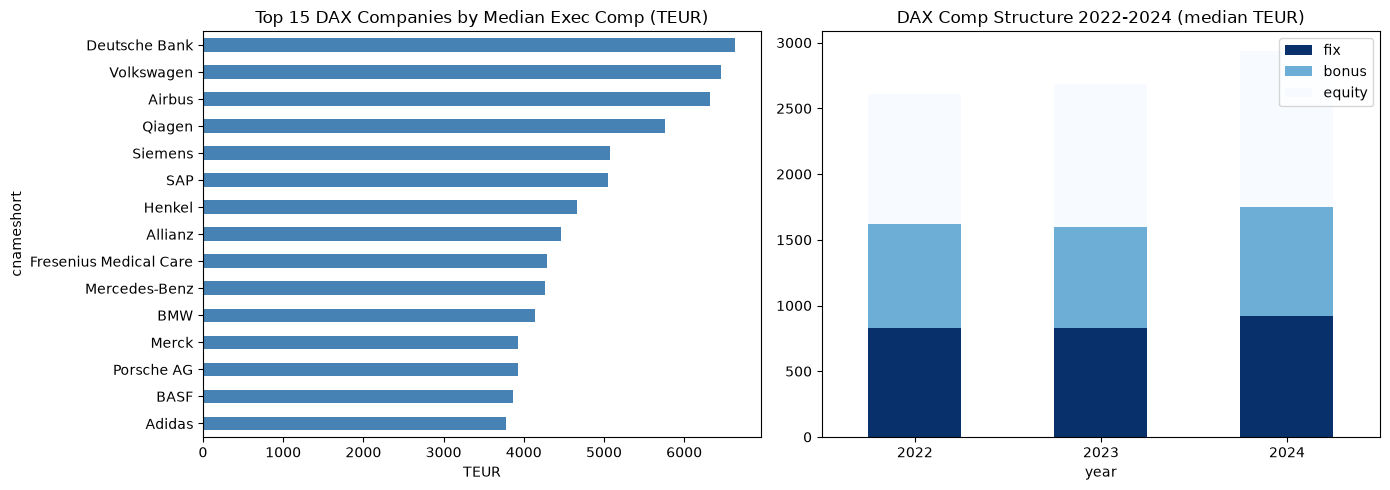

In [24]:
# DAX 2022-2024 detailed view
# comp_dax has: cnameshort, year, fix, sti, lti, total_comp
available_comp_cols = [c for c in ['cnameshort', 'year', 'fix', 'sti', 'lti', 'total_comp'] if c in comp_dax.columns]
dax_comp_named = comp_dax[available_comp_cols].copy()
dax_comp_named = dax_comp_named.rename(columns={'sti': 'bonus', 'lti': 'equity'})

if len(dax_comp_named) > 0 and 'cnameshort' in dax_comp_named.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Top 15 companies by median total comp
    top_co = dax_comp_named.groupby('cnameshort')['total_comp'].median().dropna().nlargest(15)
    top_co.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title('Top 15 DAX Companies by Median Exec Comp (TEUR)')
    axes[0].set_xlabel('TEUR')

    # Comp breakdown by year
    struct_cols = [c for c in ['fix', 'bonus', 'equity'] if c in dax_comp_named.columns]
    dax_struct = dax_comp_named.groupby('year')[struct_cols].median()
    dax_struct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Blues_r')
    axes[1].set_title('DAX Comp Structure 2022-2024 (median TEUR)')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()


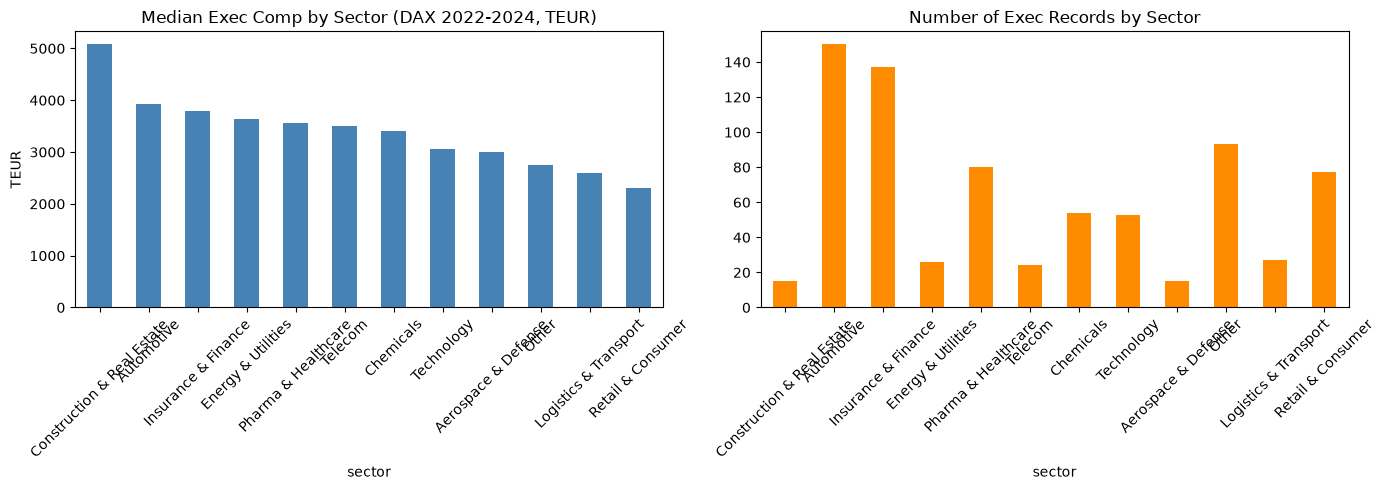

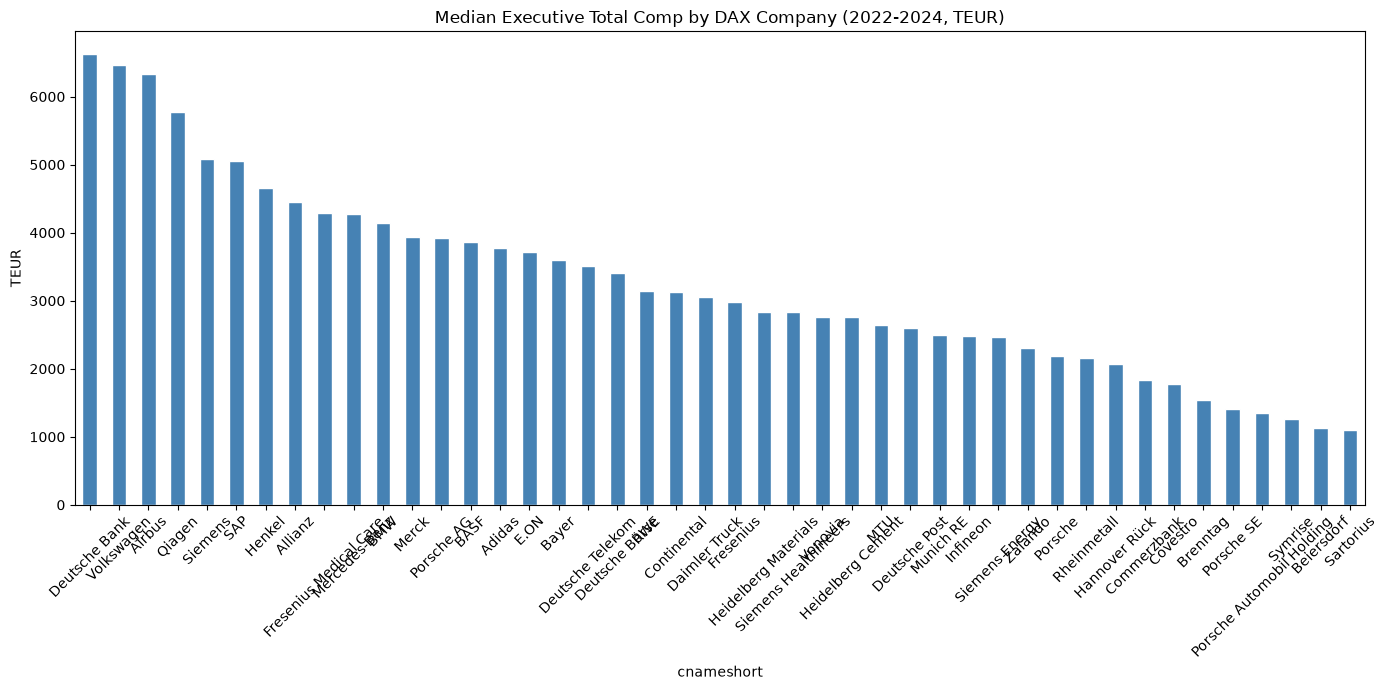

In [25]:
# Company-level summary for 2022-2024 with sector breakdown
if len(industry_map) > 0 and 'sector' in comp_dax.columns:
    sector_comp = comp_dax.groupby('sector')['total_comp'].agg(['median', 'count']).sort_values('median', ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sector_comp['median'].plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Median Exec Comp by Sector (DAX 2022-2024, TEUR)')
    axes[0].set_ylabel('TEUR')
    axes[0].tick_params(axis='x', rotation=45)
    sector_comp['count'].plot(kind='bar', ax=axes[1], color='darkorange')
    axes[1].set_title('Number of Exec Records by Sector')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

# Per-company median total comp
comp_by_co = comp_dax.groupby('cnameshort')['total_comp'].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 7))
comp_by_co.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Median Executive Total Comp by DAX Company (2022-2024, TEUR)')
ax.set_ylabel('TEUR')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


---
## 7. Feature Engineering for Prediction

In [26]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Build model-ready DataFrame
model_df = unified.copy()

# log-transform the target and skewed features
model_df['log_total_comp'] = np.log1p(model_df['total_comp'])
model_df['log_revenue'] = np.log1p(model_df['revenue_eur'].clip(lower=0))
model_df['log_assets'] = np.log1p(model_df['assets_eur'].clip(lower=0))
model_df['log_empl'] = np.log1p(model_df['empl'].clip(lower=0))
model_df['log_fix'] = np.log1p(model_df['fix'].clip(lower=0))

# encode categoricals
for col in ['size_bucket', 'sector', 'source']:
    le = LabelEncoder()
    model_df[f'{col}_enc'] = le.fit_transform(model_df[col].fillna('Unknown').astype(str))

FEATURE_COLS = [
    'year',
    'ceo_flag',
    'female',
    'log_revenue',
    'log_assets',
    'log_empl',
    'log_fix',
    'roa',
    'size_bucket_enc',
    'sector_enc',
    'source_enc',
]

TARGET = 'log_total_comp'

df_model = model_df[FEATURE_COLS + [TARGET]].dropna(subset=[TARGET])
print(f'Model dataset: {df_model.shape}')
print(f'Features with any value: {df_model[FEATURE_COLS].notna().any().sum()}')
print(f'NaN fraction per feature:')
print((df_model[FEATURE_COLS].isna().mean() * 100).round(1))

Model dataset: (7468, 12)
Features with any value: 11
NaN fraction per feature:
year                0.0
ceo_flag            0.0
female              0.0
log_revenue        92.5
log_assets         92.5
log_empl           82.2
log_fix             0.0
roa                92.5
size_bucket_enc     0.0
sector_enc          0.0
source_enc          0.0
dtype: float64


In [27]:
X = df_model[FEATURE_COLS]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

# Impute + scale pipeline
imputer = SimpleImputer(strategy='median')

models = {
    'Ridge Regression': Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Random Forest': Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('model', GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42))
    ]),
}

results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    # convert log MAE back to TEUR
    mae_teur = np.expm1(mae)
    results[name] = {'MAE (log)': mae, 'R²': r2, 'MAE (TEUR ~)': mae_teur}
    print(f'{name:25s}: R²={r2:.3f}, MAE={mae:.3f} ({mae_teur:.0f} TEUR)')

best_name = max(results, key=lambda k: results[k]['R²'])
best_model = models[best_name]
print(f'\nBest model: {best_name}')

Train: 5974, Test: 1494
Ridge Regression         : R²=0.645, MAE=0.366 (0 TEUR)
Random Forest            : R²=0.723, MAE=0.322 (0 TEUR)
Gradient Boosting        : R²=0.734, MAE=0.315 (0 TEUR)

Best model: Gradient Boosting


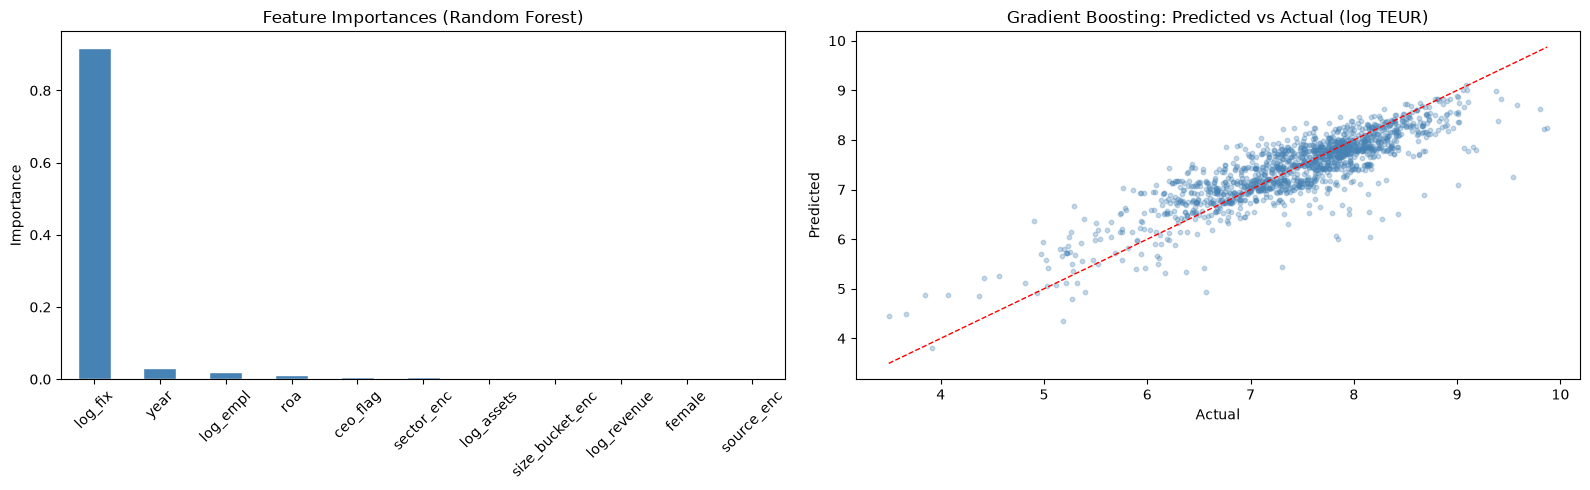

Feature importances:
 log_fix            0.9180
year               0.0299
log_empl           0.0210
roa                0.0117
ceo_flag           0.0066
sector_enc         0.0050
log_assets         0.0026
size_bucket_enc    0.0024
log_revenue        0.0016
female             0.0008
source_enc         0.0004
dtype: float64


In [28]:
# Feature importance from Random Forest
rf_model = models['Random Forest'].named_steps['model']
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

importances.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Feature Importances (Random Forest)')
axes[0].set_ylabel('Importance')
axes[0].tick_params(axis='x', rotation=45)

# Predicted vs actual on test set
y_pred_best = best_model.predict(X_test)
axes[1].scatter(y_test, y_pred_best, alpha=0.3, s=10, color='steelblue')
lo, hi = y_test.min(), y_test.max()
axes[1].plot([lo, hi], [lo, hi], 'r--', lw=1)
axes[1].set_title(f'{best_name}: Predicted vs Actual (log TEUR)')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()
print('Feature importances:\n', importances.round(4))

In [30]:
# Residual analysis — identify systematic over/underestimation
test_df = X_test.copy()
test_df['actual'] = np.expm1(y_test)
test_df['predicted'] = np.expm1(y_pred_best)
test_df['residual_pct'] = (test_df['predicted'] - test_df['actual']) / test_df['actual'] * 100

print('Residual by source:')
test_df['source_enc_back'] = test_df['source_enc']  # encoded, limited interpretability
print(test_df.groupby('source_enc')['residual_pct'].describe().round(1))

print('\nResidual by size_bucket_enc:')
print(test_df.groupby('size_bucket_enc')['residual_pct'].describe().round(1))

Residual by source:
             count  mean   std   min   25%  50%   75%    max
source_enc                                                  
0           1334.0   8.0  48.2 -89.8 -23.0 -2.8  28.3  329.1
1            160.0   2.4  34.7 -80.1 -10.9 -0.5  13.5  195.2

Residual by size_bucket_enc:
                  count  mean   std   min   25%   50%   75%    max
size_bucket_enc                                                   
0                  24.0  -3.3  31.2 -59.0 -25.5  -3.8  13.2   64.5
1                   6.0  -0.1  37.4 -38.2 -22.5 -13.4  17.8   62.0
2                 142.0   2.6  32.7 -80.1  -8.5   1.4  12.8  195.2
3                   4.0   4.5  23.5 -21.7  -7.3   2.4  14.2   34.8
4                1228.0   8.6  49.5 -89.8 -23.2  -2.9  31.6  329.1
5                  90.0   1.9  34.0 -66.7 -19.4  -2.8  15.6  105.5


---
## 8. Compensation Benchmarking
Use the trained model to benchmark any executive's compensation against peers.

In [31]:
# Fit label encoders once, reuse across calls
_le_size   = LabelEncoder().fit(unified['size_bucket'].fillna('Unknown').astype(str))
_le_sector = LabelEncoder().fit(unified['sector'].fillna('Unknown').astype(str))
_le_source = LabelEncoder().fit(unified['source'].fillna('Unknown').astype(str))

def _safe_transform(le, value, fallback='Unknown'):
    """Transform value through LabelEncoder; fall back to 'Unknown' if unseen."""
    if value not in le.classes_:
        value = fallback
    return le.transform([value])[0]


def predict_comp(model, year, ceo_flag, female, revenue_eur, assets_eur, empl,
                 fix_teur, roa=None, size_bucket_val='Unknown', sector='Unknown',
                 source='academic_2008-2020'):
    """Predict total compensation (in TEUR) for an executive profile."""
    row = pd.DataFrame([{
        'year':            year,
        'ceo_flag':        ceo_flag,
        'female':          female,
        'log_revenue':     np.log1p(max(revenue_eur, 0)),
        'log_assets':      np.log1p(max(assets_eur, 0)),
        'log_empl':        np.log1p(max(empl, 0)),
        'log_fix':         np.log1p(max(fix_teur, 0)),
        'roa':             roa,
        'size_bucket_enc': _safe_transform(_le_size,   size_bucket_val),
        'sector_enc':      _safe_transform(_le_sector, sector),
        'source_enc':      _safe_transform(_le_source, source),
    }])
    return np.expm1(model.predict(row[FEATURE_COLS])[0])


print('Known sectors:', sorted(_le_sector.classes_))
print('Known sources:', sorted(_le_source.classes_))

# Example: CEO of a large automotive company in 2022
pred = predict_comp(
    best_model,
    year=2022,
    ceo_flag=1,
    female=0,
    revenue_eur=80_000_000,
    assets_eur=200_000_000,
    empl=100_000,
    fix_teur=2_500,
    roa=0.05,
    size_bucket_val='Mega (25k+)',
    sector='Automotive',
    source='dax_2022-2024'
)
print(f'Predicted total compensation: {pred:,.0f} TEUR = {pred/1000:,.1f}M EUR')


Known sectors: ['Aerospace & Defense', 'Automotive', 'Chemicals', 'Construction & Real Estate', 'Energy & Utilities', 'Insurance & Finance', 'Logistics & Transport', 'Other', 'Pharma & Healthcare', 'Retail & Consumer', 'Technology', 'Telecom', 'Unknown']
Known sources: ['academic_2008-2020', 'dax_2022-2024']
Predicted total compensation: 5,914 TEUR = 5.9M EUR


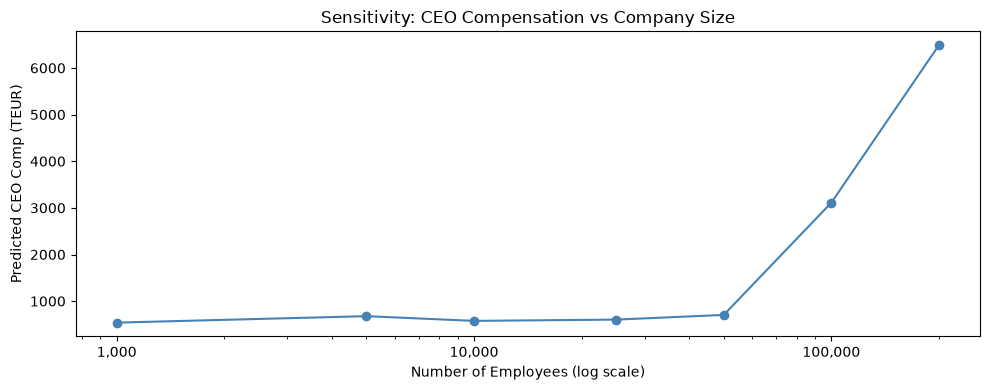

 employees         size_bucket  predicted_comp_teur
      1000       Large (1k-5k)           539.400662
      5000 Very Large (5k-25k)           678.077120
     10000 Very Large (5k-25k)           576.766271
     25000         Mega (25k+)           604.209574
     50000         Mega (25k+)           704.883722
    100000         Mega (25k+)          3111.012957
    200000         Mega (25k+)          6487.654654


In [32]:
# Sensitivity analysis: how does predicted comp vary with company size?
employee_ranges = [1000, 5000, 10000, 25000, 50000, 100000, 200000]
predictions = []

for n_empl in employee_ranges:
    sb = size_bucket(n_empl)
    p = predict_comp(
        best_model,
        year=2020,
        ceo_flag=1, female=0,
        revenue_eur=n_empl * 300,
        assets_eur=n_empl * 500,
        empl=n_empl,
        fix_teur=max(500, n_empl // 100),
        roa=0.05,
        size_bucket_val=sb,
        sector='Unknown',
        source='academic_2008-2020'
    )
    predictions.append({'employees': n_empl, 'size_bucket': sb, 'predicted_comp_teur': p})

sens_df = pd.DataFrame(predictions)
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(sens_df['employees'], sens_df['predicted_comp_teur'], marker='o', color='steelblue')
ax.set_xlabel('Number of Employees (log scale)')
ax.set_ylabel('Predicted CEO Comp (TEUR)')
ax.set_title('Sensitivity: CEO Compensation vs Company Size')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()
print(sens_df.to_string(index=False))


---
## 9. Export Processed Data

In [33]:
# Save unified dataset for downstream use
unified.to_csv('data/unified_comp.csv', index=False)
cy_orbis.to_csv('data/company_year_orbis.csv', index=False)
print('Exported:')
print(f'  data/unified_comp.csv  ({len(unified):,} rows)')
print(f'  data/company_year_orbis.csv  ({len(cy_orbis):,} rows)')

Exported:
  data/unified_comp.csv  (7,468 rows)
  data/company_year_orbis.csv  (1,467 rows)
